# Perturbation manifold motion analysis

For each KO gene, measure how much its `(drug, gene)` row moves across the
16 drug contexts in the perturbation embedding (PCA space). High-motion KOs
are *context-dependent* — the same KO produces different transcriptional
states under different drugs. Then run pathway enrichment on the high-motion
gene list to ask: are context-dependent KOs functionally clustered?

## Inputs
- `PerturbationEmbeddings/perturbation_embeddings.h5ad` — saved by notebook 11

## Outputs
- `PerturbationEmbeddings/per_gene_motion.csv` — one row per gene, motion stats
- `PerturbationEmbeddings/motion_top_genes_enrichment.csv` — pathway enrichment table

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [2]:
PROJECT_DIR = Path('/home/beraslan/Projects/ChemoGeneticScreens')
EMB_DIR     = PROJECT_DIR / 'PerturbationEmbeddings'
GMT_DIR     = Path('/home/beraslan/Projects/ModuleFinder/MuVI/msigdb')
GMT_PATHS   = [
    GMT_DIR / 'c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt',
    GMT_DIR / 'c2.cp.kegg_medicus.v2024.1.Hs.symbols.gmt',
    GMT_DIR / 'c2.cp.reactome.v7.5.1.symbols.gmt',
    GMT_DIR / 'h.all.v7.5.1.symbols.gmt',
    GMT_DIR / 'c5.go.bp.v7.5.1.symbols.gmt',
]

# Knobs
N_PCS         = 250      # how many PCs to use for motion
MIN_DRUGS     = 3       # require gene tested in ≥ this many drugs
TOP_N         = 200     # top high-motion genes for ORA

## Load embeddings

In [3]:
adata = ad.read_h5ad(EMB_DIR / 'perturbation_embeddings.h5ad')
print(f'AnnData: {adata.n_obs:,} (drug, gene) rows × {adata.n_vars} genes')
print(f'  PCA shape: {adata.obsm["X_pca"].shape}')
print(f'  drugs: {adata.obs["drug"].nunique()}, unique perts: {adata.obs["gene"].nunique()}')

AnnData: 30,704 (drug, gene) rows × 14639 genes
  PCA shape: (30704, 250)
  drugs: 16, unique perts: 1919


## Per-gene motion: distance from each drug to its **batch-matched** DMSO baseline

For each KO gene, build TWO DMSO baselines:

- $\hat{\mu}_g^{\,\text{DMSO\_round2}}$  — unit vector of the `DMSO_round2` row in PCA space (batch1 reference)
- $\hat{\mu}_g^{\,\text{DMSO\_round2\_batch2}}$ — same for `DMSO_round2_batch2` (batch2 reference)

For each `(drug, gene)` row, look up the drug's batch (from `SampleSheet.csv`) and compute cosine distance to the **same-batch** DMSO baseline. This isolates drug effect from the technical batch shift between the two DMSO replicates.

$$\text{motion}[g] = \text{mean}_{d \notin \text{DMSO}} \, \big(1 - \hat{x}_{g, d} \cdot \hat{\mu}_g^{\,\text{DMSO}(\text{batch}(d))}\big)$$

Range $[0, 2]$. **Low** = drug treatment doesn't pull the KO away from same-batch DMSO (drug-resistant / constitutive). **High** = drug treatment swings the KO's response (drug-modulated). The two DMSOs themselves sit at exactly zero against their own batch's baseline — useful as a sanity floor on the per-drug plot.

In [4]:
# Batch-of-drug lookup, mirrored from TextFiles/SampleSheet.csv (Round2 only).
BATCH_DRUGS = {
    'batch1': ['AR-A014418', 'AZD4573', 'CHIR-98014', 'Lexibulin', 'PP121',
               'Romidepsin', 'Stattic', 'DMSO_round2'],
    'batch2': ['Bisindolylmaleimide-I', 'DG-172', 'JTE-607', 'LDN-193189',
               'LY2090314', 'NSC95397', 'VX-11e', 'DMSO_round2_batch2'],
}
DMSO_OF_BATCH = {'batch1': 'DMSO_round2', 'batch2': 'DMSO_round2_batch2'}
DMSO_DRUGS    = set(DMSO_OF_BATCH.values())
BATCH_OF_DRUG = {d: b for b, ds in BATCH_DRUGS.items() for d in ds}

X      = adata.obsm['X_pca'][:, :N_PCS]
genes  = adata.obs['gene'].values
drugs  = adata.obs['drug'].values

unknown = sorted(set(np.unique(drugs)) - set(BATCH_OF_DRUG))
if unknown:
    raise RuntimeError(f'Drugs missing batch mapping: {unknown}')

is_dmso   = np.isin(drugs, list(DMSO_DRUGS))
batch_arr = np.array([BATCH_OF_DRUG[d] for d in drugs])

# Pre-compute unit-length rows (used for centroids and cos dists)
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-12)

# Per-gene per-batch DMSO centroid: the unit vector of that batch's single
# DMSO row for that gene (1 row per gene per batch in this embedding).
gene_to_dmso_b1 = {}
gene_to_dmso_b2 = {}
for g in np.unique(genes):
    for b_label, dmso_drug in DMSO_OF_BATCH.items():
        m = (genes == g) & (drugs == dmso_drug)
        if m.sum() == 0:
            continue
        v  = X_norm[m].mean(axis=0)
        mu = v / max(np.linalg.norm(v), 1e-12)
        (gene_to_dmso_b1 if b_label == 'batch1' else gene_to_dmso_b2)[g] = mu
print(f'Genes with batch1 DMSO baseline: {len(gene_to_dmso_b1):,}')
print(f'Genes with batch2 DMSO baseline: {len(gene_to_dmso_b2):,}')

# Per-row cosine distance using batch-matched DMSO
row_cos = np.full(adata.n_obs, np.nan)
for i in range(adata.n_obs):
    g = genes[i]
    mu = gene_to_dmso_b1.get(g) if batch_arr[i] == 'batch1' else gene_to_dmso_b2.get(g)
    if mu is not None:
        row_cos[i] = 1.0 - X_norm[i] @ mu

# Per-gene motion = mean cos_dist over non-DMSO rows for that gene
rows = []
for g in np.unique(genes):
    if g not in gene_to_dmso_b1 and g not in gene_to_dmso_b2:
        continue
    mask_drug = (genes == g) & ~is_dmso
    cd        = row_cos[mask_drug]
    cd_valid  = cd[~np.isnan(cd)]
    if len(cd_valid) < MIN_DRUGS:
        continue
    rows.append({
        'gene':       g,
        'n_drugs':    int(len(cd_valid)),
        'has_b1_ref': g in gene_to_dmso_b1,
        'has_b2_ref': g in gene_to_dmso_b2,
        'motion':     float(cd_valid.mean()),
        'motion_max': float(cd_valid.max()),
        'motion_min': float(cd_valid.min()),
    })

motion_df = pd.DataFrame(rows).sort_values('motion', ascending=False).reset_index(drop=True)
print(f'\n{len(motion_df):,} genes pass MIN_DRUGS={MIN_DRUGS} (non-DMSO drug count, batch-matched)')
print('\nTop 20 by motion (batch-matched DMSO baseline):')
print(motion_df.head(20).to_string())
print('\nBottom 5:')
print(motion_df.tail(5).to_string())

motion_df.to_csv(EMB_DIR / 'per_gene_motion.csv', index=False)
print(f'\nSaved {EMB_DIR / "per_gene_motion.csv"}')

Genes with batch1 DMSO baseline: 1,919
Genes with batch2 DMSO baseline: 1,919

1,919 genes pass MIN_DRUGS=3 (non-DMSO drug count, batch-matched)

Top 20 by motion (batch-matched DMSO baseline):
        gene  n_drugs  has_b1_ref  has_b2_ref    motion  motion_max  motion_min
0       MTA2       14        True        True  0.886716    1.354648    0.546491
1       NPM1       14        True        True  0.865489    1.141049    0.544521
2     RALGDS       14        True        True  0.808381    1.096705    0.565948
3        TAZ       14        True        True  0.806290    1.278501    0.463462
4     CAMTA2       14        True        True  0.798326    1.180964    0.555785
5     CRELD2       14        True        True  0.794759    1.037455    0.435010
6   SLC25A46       14        True        True  0.788908    1.125480    0.510864
7     DLGAP5       14        True        True  0.785141    1.113857    0.492557
8      RBM34       14        True        True  0.772917    1.053081    0.430163
9     

/tmp/ipykernel_193153/2396609035.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


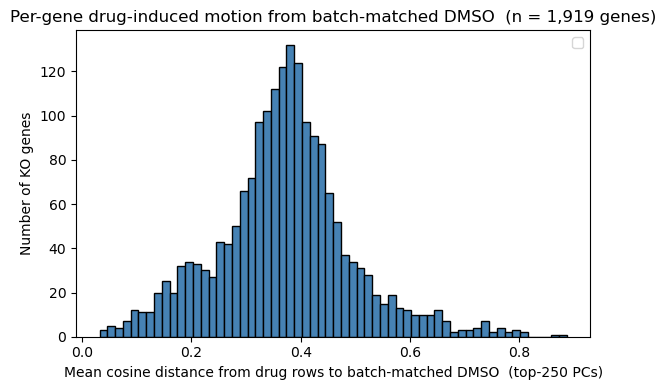

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(motion_df['motion'], bins=60, color='steelblue', edgecolor='black')
cutoff = motion_df['motion'].iloc[TOP_N - 1]
ax.set_xlabel(f'Mean cosine distance from drug rows to batch-matched DMSO  (top-{N_PCS} PCs)')
ax.set_ylabel('Number of KO genes')
ax.set_title(f'Per-gene drug-induced motion from batch-matched DMSO  (n = {len(motion_df):,} genes)')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_193153/2352032400.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


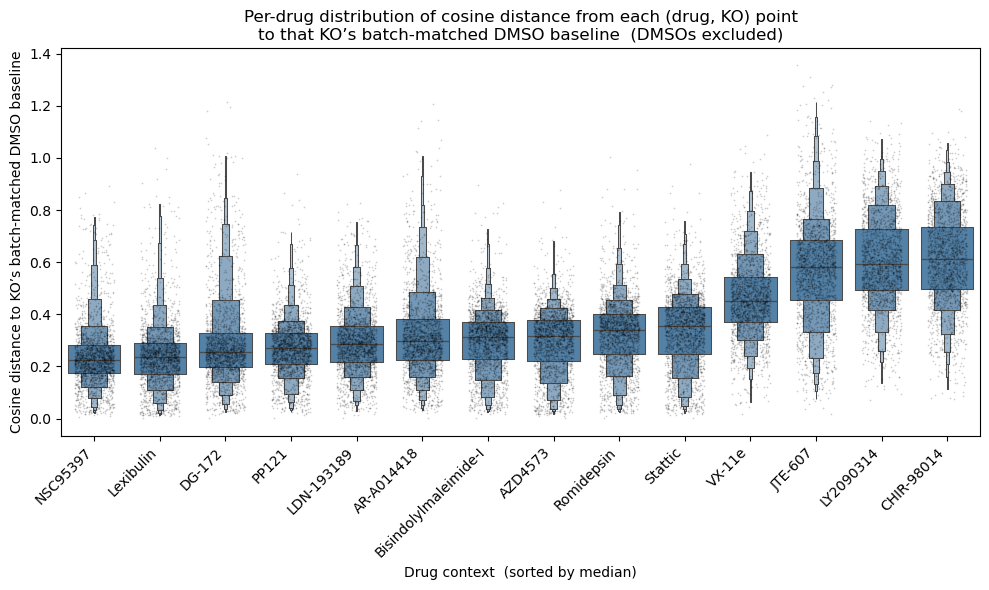


Per-drug summary (sorted by median):
                         median      mean       std  count
drug                                                      
NSC95397               0.225866  0.242692  0.127818   1919
Lexibulin              0.235300  0.243519  0.130221   1919
DG-172                 0.256329  0.290833  0.171408   1919
PP121                  0.270878  0.272806  0.113321   1919
LDN-193189             0.285615  0.295400  0.128102   1919
AR-A014418             0.298790  0.321464  0.164352   1919
Bisindolylmaleimide-I  0.311915  0.299761  0.122375   1919
AZD4573                0.316617  0.298189  0.125890   1919
Romidepsin             0.339853  0.327058  0.135541   1919
Stattic                0.356086  0.337380  0.143516   1919
VX-11e                 0.452680  0.462925  0.153885   1919
JTE-607                0.581504  0.571081  0.204079   1919
LY2090314              0.592135  0.604547  0.178032   1919
CHIR-98014             0.611862  0.614464  0.182219   1919


In [6]:
# Per-drug distribution of cosine distance from each (drug, gene) row to its
# gene's batch-matched DMSO baseline. DMSOs themselves excluded — they sit at
# exactly zero against their own batch's centroid.
#
# Plot: boxenplot (letter-value plot) — robust to skewed distributions and
# narrow IQRs. Faint stripplot overlay shows individual KO points.
#
# Note: cast drug column to plain string (and explicitly filter order)
# because adata.obs['drug'] is a categorical — without these steps, unused
# DMSO categories remain on the x-axis even after row filtering.

non_dmso = ~np.isin(drugs, list(DMSO_DRUGS))
per_drug = pd.DataFrame({
    'drug':     np.asarray(drugs[non_dmso], dtype=str),
    'cos_dist': row_cos[non_dmso],
}).dropna()
order = (per_drug.groupby('drug', observed=True)['cos_dist']
                  .median().sort_values().index.tolist())
order = [d for d in order if d not in DMSO_DRUGS]   # belt-and-braces

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxenplot(
    data=per_drug, x='drug', y='cos_dist',
    order=order, ax=ax, showfliers=False, color='steelblue',
)
sns.stripplot(
    data=per_drug, x='drug', y='cos_dist',
    order=order, ax=ax, color='black', size=1.2, alpha=0.20, jitter=0.30,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Cosine distance to KO\u2019s batch-matched DMSO baseline')
ax.set_xlabel('Drug context  (sorted by median)')
ax.set_title(
    'Per-drug distribution of cosine distance from each (drug, KO) point\n'
    'to that KO\u2019s batch-matched DMSO baseline  (DMSOs excluded)'
)
plt.tight_layout()
plt.show()

print('\nPer-drug summary (sorted by median):')
print(per_drug.groupby('drug', observed=True)['cos_dist']
       .agg(['median', 'mean', 'std', 'count']).loc[order])

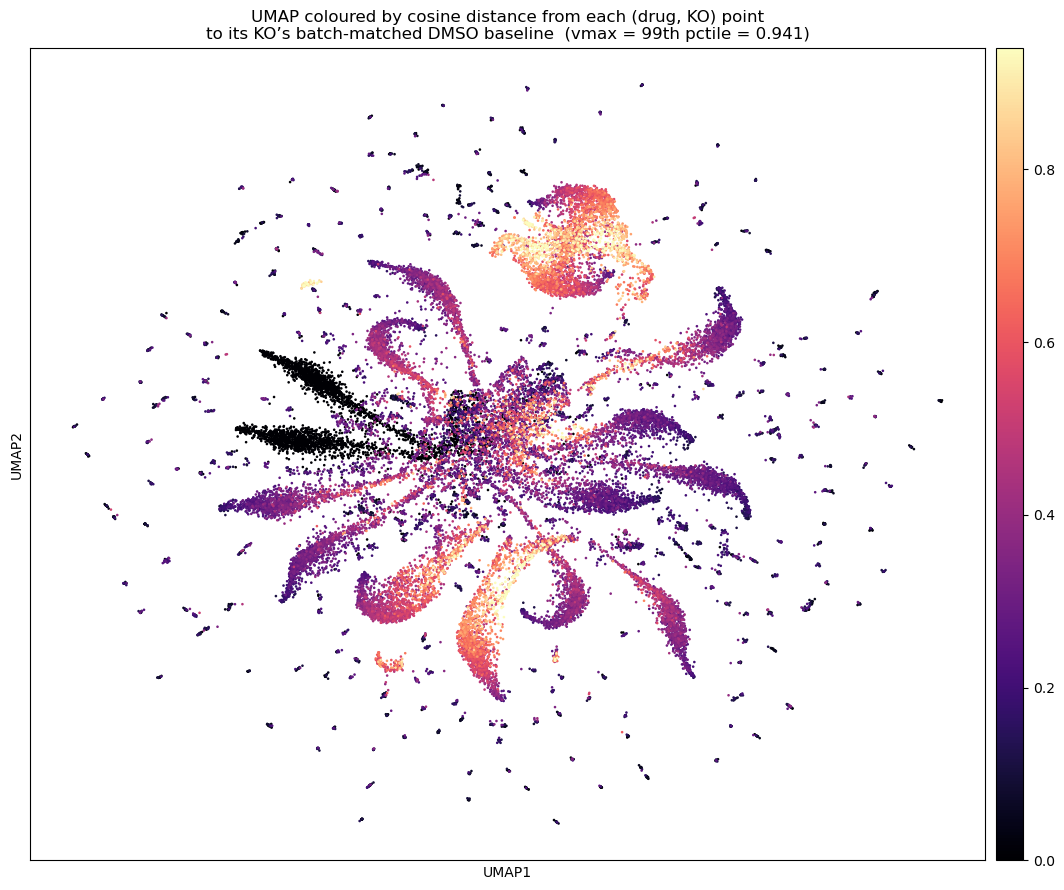

In [7]:
# UMAP coloured by per-(drug, gene) cosine distance to the row's
# batch-matched DMSO baseline. Each point = one (drug, KO) sample;
# colour = how far it sits from its KO's same-batch DMSO.
#
# DMSO rows are exactly 0 against their own batch baseline (darkest
# end of the colormap). Bright points = drug-treatment + KO combinations
# that diverge most from no-drug behaviour.

adata.obs['cos_dist_to_dmso'] = row_cos

# Clip vmax at the 99th percentile (over non-DMSO rows) so a few outliers
# don't wash out the dynamic range of the colormap.
_nondmso = ~np.isin(adata.obs['drug'].values, list(DMSO_DRUGS))
vmax = float(np.nanquantile(row_cos[_nondmso], 0.99))

fig, ax = plt.subplots(figsize=(11, 9))
sc.pl.umap(
    adata,
    color='cos_dist_to_dmso',
    size=14,
    cmap='magma',
    vmin=0,
    vmax=vmax,
    sort_order=True,   # high-cos_dist points drawn on top
    title=(
        'UMAP coloured by cosine distance from each (drug, KO) point\n'
        f"to its KO\u2019s batch-matched DMSO baseline  (vmax = 99th pctile = {vmax:.3f})"
    ),
    ax=ax,
    show=False,
)
plt.tight_layout()
plt.show()

## Cluster KOs by their context-dependence fingerprint, then ORA per cluster

A more general view than the top-N motion ORA above. Build a `(KO × drug)`
matrix where each row is a gene's vector of cosine distances to its
same-batch DMSO baseline across the 14 non-DMSO drugs. This is the gene's
**context-dependence fingerprint** — full information, not just a scalar.

Pipeline:
1. Pivot `row_cos` into the `(gene × drug)` fingerprint matrix
2. Wrap as an AnnData; per-drug column z-score so drug-magnitude differences don't dominate
3. PCA → kNN graph → Leiden → UMAP — standard scanpy clustering
4. Hypergeometric ORA per cluster against MSigDB (KEGG / Reactome / Hallmark / GO BP), background = all clustered KOs

Each cluster = a group of KOs that share a context-dependence pattern across drugs.
Per-cluster enrichments tell us whether those groupings have known functional coherence.

In [ ]:
# Build the (gene × drug) cos_dist fingerprint matrix
_df = pd.DataFrame({
    'gene':     adata.obs['gene'].values,
    'drug':     adata.obs['drug'].values,
    'cos_dist': row_cos,
})
_df = _df[~_df['drug'].isin(DMSO_DRUGS)]   # drop DMSO columns (all 0 against own batch)

fingerprint = _df.pivot_table(
    index='gene', columns='drug', values='cos_dist', aggfunc='mean'
)
print(f'Raw fingerprint matrix: {fingerprint.shape}')
print(f'\nPer-drug NaN count:')
print(fingerprint.isna().sum().to_string())

# Save the NaN-PRESERVING fingerprint BEFORE imputation: a value is always a genuine cosine
# distance and NaN means the (drug, gene) pair was not measured. Downstream feature tables
# (e.g. notebook 22) use this so "missing" stays distinct from a true cosine of ~0.
fingerprint.to_csv(EMB_DIR / 'per_gene_per_drug_cos_dist_raw.csv')
print(f'\nSaved {EMB_DIR / "per_gene_per_drug_cos_dist_raw.csv"} (NaN-preserving)')

# For the CLUSTERING below only: require ≥ MIN_DRUGS non-NaN columns per gene and fill the
# rest with 0 (cos_dist = 0 ~ "no effect"). Do NOT reuse this imputed matrix as a feature
# table — use the *_raw.csv above for that.
fingerprint = fingerprint.dropna(thresh=MIN_DRUGS)
fingerprint = fingerprint.fillna(0.0)
print(f'\nAfter dropna(thresh={MIN_DRUGS}) + fillna(0): {fingerprint.shape}')

fingerprint.to_csv(EMB_DIR / 'per_gene_per_drug_cos_dist.csv')
print(f'Saved {EMB_DIR / "per_gene_per_drug_cos_dist.csv"} (fillna(0), for clustering)')

In [10]:
fingerprint

drug,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,
A1BG,0.128851,0.164128,0.202443,0.256613,0.087405,0.240135,0.106492,0.200721,0.120831,0.089980,0.147495,0.160919,0.169081,0.150725
AASS,0.316000,0.357325,0.433023,0.648006,0.366659,0.684068,0.389998,0.668015,0.258418,0.303694,0.299520,0.366209,0.463116,0.479373
ABCB6,0.241354,0.345531,0.298924,0.757254,0.240374,0.469996,0.226261,0.756252,0.184411,0.212480,0.247503,0.303213,0.315313,0.337282
ABCC5,0.283057,0.379420,0.381417,0.493425,0.211474,0.794809,0.255915,0.559507,0.251021,0.188844,0.275035,0.422780,0.372671,0.499903
ABCF3,0.411837,0.373254,0.334321,0.708590,0.238274,0.555607,0.739469,0.549706,0.336651,0.251264,0.329576,0.360949,0.454002,0.439230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN21,0.121393,0.040251,0.076446,0.701382,0.073641,0.259219,0.059860,0.655536,0.040936,0.066728,0.104864,0.069177,0.089808,0.458278
ZSCAN32,0.614022,0.352359,0.527154,0.990556,0.606448,0.815437,0.580247,1.058291,0.401317,0.525926,0.408853,0.396793,0.452605,0.694022
ZW10,0.418969,0.303026,0.291354,0.680536,0.333981,0.560397,0.291163,0.673740,0.337144,0.334915,0.302779,0.359195,0.319614,0.446031


In [42]:
# Wrap as AnnData; run the standard scanpy clustering pipeline
ctx_adata = ad.AnnData(
    X=fingerprint.values.astype(np.float32),
    obs=pd.DataFrame(index=fingerprint.index.astype(str)),
    var=pd.DataFrame(index=fingerprint.columns.astype(str)),
)
print(f'context AnnData: {ctx_adata.shape}  (KOs × non-DMSO drugs)')

# Per-drug column z-score so high-magnitude drugs don't dominate clustering
sc.pp.scale(ctx_adata, max_value=10)

# PCA → kNN → Leiden → UMAP
n_pca = min(20, ctx_adata.shape[1] - 1)
sc.pp.pca(ctx_adata, n_comps=n_pca)
sc.pp.neighbors(ctx_adata, n_neighbors=5, use_rep='X_pca')
sc.tl.leiden(ctx_adata, resolution=0.5, key_added='cluster')
sc.tl.umap(ctx_adata)

n_clust = ctx_adata.obs['cluster'].nunique()
print(f'\nLeiden clusters: {n_clust}')
print('Cluster sizes:')
print(ctx_adata.obs['cluster'].value_counts().sort_index().to_string())

ctx_adata.write_h5ad(EMB_DIR / 'context_clusters.h5ad')
print(f'\nSaved {EMB_DIR / "context_clusters.h5ad"}')

context AnnData: (1919, 14)  (KOs × non-DMSO drugs)

Leiden clusters: 8
Cluster sizes:
cluster
0    418
1    362
2    285
3    280
4    271
5    144
6     97
7     62

Saved /home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/context_clusters.h5ad


In [43]:
ctx_adata.obs["KO_gene"]=ctx_adata.obs.index

In [44]:
a=ctx_adata.obs

In [45]:
a.sort_values("cluster").to_csv("PertClusters.csv")

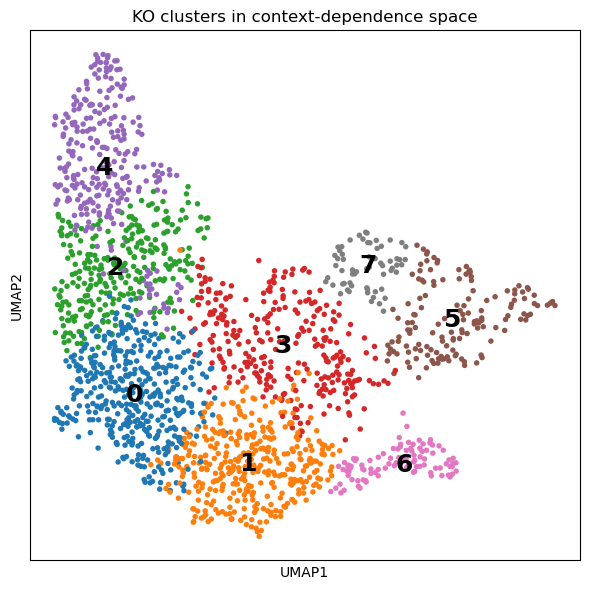

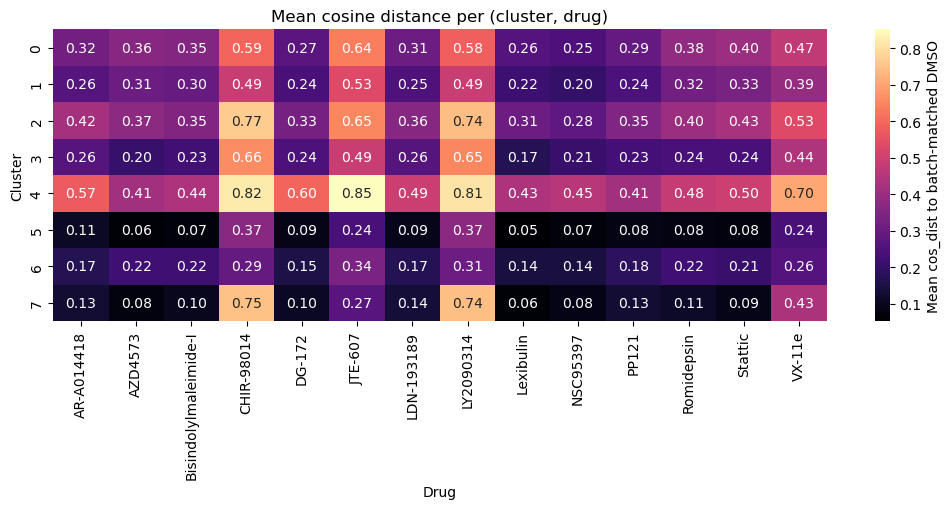

In [46]:
# Visualize: UMAP coloured by cluster, plus heatmap of mean cos_dist per (cluster, drug)
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(
    ctx_adata, color='cluster',
    legend_loc='on data', legend_fontsize=18,
    title='KO clusters in context-dependence space',
    ax=ax, show=False,
)
plt.tight_layout()
plt.show()

# Per-(cluster, drug) mean fingerprint — interpret what each cluster means
mean_per_cluster = (
    fingerprint.assign(cluster=ctx_adata.obs['cluster'].astype(str).values)
               .groupby('cluster').mean()
)
mean_per_cluster = mean_per_cluster.loc[
    sorted(mean_per_cluster.index, key=lambda x: int(x) if x.isdigit() else x)
]

fig, ax = plt.subplots(figsize=(max(10, 0.6 * mean_per_cluster.shape[1] + 2),
                                max(4, 0.4 * mean_per_cluster.shape[0] + 2)))
sns.heatmap(
    mean_per_cluster, cmap='magma',
    annot=True, fmt='.2f',
    cbar_kws={'label': 'Mean cos_dist to batch-matched DMSO'},
    ax=ax,
)
ax.set_title('Mean cosine distance per (cluster, drug)')
ax.set_xlabel('Drug')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [14]:
# Load MSigDB gene sets and define a hypergeometric ORA helper
# (used by the per-cluster enrichment cell below)
GMT_DIR   = Path('/home/beraslan/Projects/ModuleFinder/MuVI/msigdb')
GMT_PATHS = [
    GMT_DIR / 'c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt',
    GMT_DIR / 'c2.cp.kegg_medicus.v2024.1.Hs.symbols.gmt',
    GMT_DIR / 'c2.cp.reactome.v7.5.1.symbols.gmt',
    GMT_DIR / 'h.all.v7.5.1.symbols.gmt',
    GMT_DIR / 'c5.go.bp.v7.5.1.symbols.gmt',
]

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


def parse_gmt(path):
    sets = {}
    with open(path) as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 3:
                continue
            name, _url, *gns = parts
            gns = {g for g in gns if g}
            if gns:
                sets[name] = gns
    return sets


gene_sets = {}
for p in GMT_PATHS:
    if p.exists():
        gene_sets.update(parse_gmt(p))
        print(f'  loaded {p.name}')
    else:
        print(f'  SKIP missing: {p.name}')
print(f'\nTotal gene sets: {len(gene_sets):,}')


def ora(query, background, gene_sets, min_set=5, max_set=500):
    """Hypergeometric ORA via Fisher's exact test, BH q-values."""
    background = set(background)
    query      = set(query) & background
    rows = []
    N = len(background)
    K = len(query)
    for name, members in gene_sets.items():
        members = members & background
        n = len(members)
        if n < min_set or n > max_set:
            continue
        k = len(query & members)
        if k == 0:
            continue
        odds, p = fisher_exact(
            [[k, K - k], [n - k, N - n - K + k]],
            alternative='greater',
        )
        rows.append({
            'gene_set':      name,
            'set_size':      n,
            'k_in_query':    k,
            'expected':      K * n / N,
            'odds_ratio':    odds,
            'p_value':       p,
            'overlap_genes': ','.join(sorted(query & members)),
        })
    df = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
    if len(df):
        df['q_bh'] = multipletests(df['p_value'], method='fdr_bh')[1]
    return df

  loaded c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt
  loaded c2.cp.kegg_medicus.v2024.1.Hs.symbols.gmt
  loaded c2.cp.reactome.v7.5.1.symbols.gmt
  loaded h.all.v7.5.1.symbols.gmt
  loaded c5.go.bp.v7.5.1.symbols.gmt

Total gene sets: 10,167


In [15]:
# Hypergeometric ORA per cluster.
# Background = all clustered KOs (so we test pathway enrichment within
# the universe of testable KOs, not against the full transcriptome).

print('Per-cluster pathway enrichment (top 8 hits each):\n')
background = ctx_adata.obs_names.tolist()
all_results = []

cluster_order = sorted(
    ctx_adata.obs['cluster'].cat.categories,
    key=lambda x: int(x) if str(x).isdigit() else x,
)

for c in cluster_order:
    cluster_genes = ctx_adata.obs_names[ctx_adata.obs['cluster'] == c].tolist()
    res = ora(cluster_genes, background, gene_sets, min_set=5, max_set=500)
    if not len(res):
        print(f'\n--- Cluster {c}  (n={len(cluster_genes)} KOs) ---  no overlapping gene sets')
        continue
    res.insert(0, 'cluster', str(c))
    all_results.append(res)

    sig = res[res['q_bh'] < 0.10]
    print(f'\n--- Cluster {c}  (n={len(cluster_genes)} KOs, sig pathways q<0.10: {len(sig)}) ---')
    show = sig if len(sig) else res
    print(show[['gene_set','set_size','k_in_query','expected','q_bh']]
            .head(8).to_string(index=False))

if all_results:
    full = pd.concat(all_results, ignore_index=True)
    full.to_csv(EMB_DIR / 'cluster_enrichment.csv', index=False)
    print(f'\n\nSaved {EMB_DIR / "cluster_enrichment.csv"}  ({len(full):,} rows)')

Per-cluster pathway enrichment (top 8 hits each):


--- Cluster 0  (n=286 KOs, sig pathways q<0.10: 2) ---
               gene_set  set_size  k_in_query  expected     q_bh
GOBP_CELL_CELL_ADHESION       145          42 21.610214 0.014736
   GOBP_CELL_ACTIVATION       168          44 25.038041 0.074904

--- Cluster 1  (n=269 KOs, sig pathways q<0.10: 0) ---
                                                      gene_set  set_size  k_in_query  expected    q_bh
                       GOBP_ENDOTHELIAL_CELL_APOPTOTIC_PROCESS        11           6  1.541949 0.99997
                             REACTOME_ONCOGENIC_MAPK_SIGNALING        16           7  2.242835 0.99997
        GOBP_CELLULAR_MODIFIED_AMINO_ACID_BIOSYNTHETIC_PROCESS         6           4  0.841063 0.99997
                                           HALLMARK_MYOGENESIS        32          10  4.485670 0.99997
GOBP_NEGATIVE_REGULATION_OF_ENDOTHELIAL_CELL_APOPTOTIC_PROCESS         7           4  0.981240 0.99997
                        